# Hierarchical Risk Parity (HRP): Asignación Jerárquica de Riesgo

## Introducción

El algoritmo **Hierarchical Risk Parity (HRP)**, propuesto por Marcos López de Prado en 2016, representa un avance significativo en la teoría de construcción de portafolios. Este método aborda una limitación fundamental de los enfoques tradicionales de optimización de portafolios (como Markowitz): **la necesidad de invertir la matriz de covarianza**.

### ¿Por qué es problemática la inversión de la matriz de covarianza?

La optimización clásica de media-varianza requiere calcular $\Sigma^{-1}$ (la inversa de la matriz de covarianza). Esto genera varios problemas:

1. **Inestabilidad numérica**: Cuando los activos están altamente correlacionados, la matriz de covarianza se vuelve casi singular, haciendo que su inversión sea numéricamente inestable.

2. **Sensibilidad a errores de estimación**: Pequeños errores en la estimación de la covarianza se amplifican dramáticamente al invertir la matriz.

3. **Portafolios extremos**: Los pesos resultantes pueden ser muy sensibles a cambios menores en los datos, produciendo asignaciones poco intuitivas.

### La solución de HRP

HRP evita completamente la inversión de la matriz de covarianza mediante tres pasos innovadores:

1. **Clustering jerárquico**: Agrupa activos similares usando técnicas de aprendizaje automático.
2. **Quasi-diagonalización**: Reordena la matriz de covarianza según la estructura jerárquica.
3. **Bisección recursiva**: Asigna pesos de forma recursiva, respetando la estructura de clusters.

## 1. Preparación del entorno e importación de librerías

Comenzamos importando las librerías necesarias para implementar HRP:
- **NumPy**: Para operaciones matriciales y cálculos numéricos
- **Pandas**: Para manejo de datos financieros
- **SciPy**: Para clustering jerárquico y funciones de distancia
- **Matplotlib/Seaborn**: Para visualización
- **yfinance**: Para obtener datos reales del mercado

In [1]:
# Importación de librerías fundamentales
import numpy as np
import pandas as pd

# Librerías para clustering jerárquico
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Datos financieros
import yfinance as yf

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)  # Para reproducibilidad

## 2. Obtención de datos financieros

Descargaremos datos históricos de varios activos para demostrar el algoritmo HRP. Utilizaremos un conjunto diversificado de ETFs que representan diferentes clases de activos:

- **SPY**: S&P 500 (Renta variable EE.UU.)
- **EFA**: Mercados desarrollados internacionales
- **EEM**: Mercados emergentes
- **TLT**: Bonos del Tesoro a largo plazo
- **GLD**: Oro
- **VNQ**: Bienes raíces (REITs)
- **LQD**: Bonos corporativos investment grade

In [2]:
# Definir los tickers de los activos
tickers = ['SPY', 'EFA', 'EEM', 'TLT', 'GLD', 'VNQ', 'LQD']

# Descargar datos históricos (últimos 5 años)
print("Descargando datos de Yahoo Finance...")
datos = yf.download(tickers, start='2019-01-01', end='2024-01-01', progress=False)['Close']

# Verificar los datos descargados
print(f"\nDimensiones de los datos: {datos.shape}")
print(f"Período: {datos.index[0].strftime('%Y-%m-%d')} a {datos.index[-1].strftime('%Y-%m-%d')}")
datos.head()

Descargando datos de Yahoo Finance...

Dimensiones de los datos: (1258, 7)
Período: 2019-01-02 a 2023-12-29


Ticker,EEM,EFA,GLD,LQD,SPY,TLT,VNQ
Date,,,,,,,
2019-01-02,33.319096,47.469452,121.330002,87.847176,224.995331,99.843346,56.117092
2019-01-03,32.714993,47.040565,122.430000,87.886002,219.626297,100.979530,56.509418
2019-01-04,33.770035,48.480995,121.440002,87.831635,226.982910,99.810661,57.170967
2019-01-07,33.846615,48.667110,121.860001,87.839424,228.772568,99.516411,57.732533
2019-01-08,33.974243,48.982708,121.529999,88.033493,230.921936,99.254829,58.924870


In [3]:
# Calcular rendimientos logarítmicos diarios
# Los rendimientos logarítmicos son preferidos porque son aditivos en el tiempo
rendimientos = np.log(datos / datos.shift(1)).dropna()

print("Estadísticas descriptivas de los rendimientos diarios:")
print(rendimientos.describe().round(4))

Estadísticas descriptivas de los rendimientos diarios:
Ticker        EEM        EFA        GLD        LQD        SPY        TLT  \
count   1257.0000  1257.0000  1257.0000  1257.0000  1257.0000  1257.0000   
mean       0.0001     0.0003     0.0004     0.0001     0.0006    -0.0001   
std        0.0142     0.0125     0.0094     0.0069     0.0133     0.0111   
min       -0.1333    -0.1164    -0.0552    -0.0513    -0.1159    -0.0690   
25%       -0.0069    -0.0054    -0.0045    -0.0027    -0.0050    -0.0069   
50%        0.0007     0.0008     0.0006     0.0004     0.0009     0.0001   
75%        0.0077     0.0067     0.0056     0.0031     0.0072     0.0063   
max        0.0775     0.0813     0.0474     0.0713     0.0867     0.0725   

Ticker        VNQ  
count   1257.0000  
mean       0.0003  
std        0.0160  
min       -0.1951  
25%       -0.0065  
50%        0.0009  
75%        0.0076  
max        0.0861  


## 3. Cálculo de la matriz de correlación y covarianza

El primer paso del algoritmo HRP requiere calcular:
1. **Matriz de correlación** ($\rho$): Mide la relación lineal entre activos (valores entre -1 y 1)
2. **Matriz de covarianza** ($\Sigma$): Combina la correlación con las volatilidades individuales

La matriz de correlación es fundamental porque HRP utiliza las correlaciones para agrupar activos similares.

In [4]:
# Calcular matriz de covarianza
# La matriz de covarianza mide cómo varían conjuntamente los rendimientos de los activos
covarianza = rendimientos.cov()

# Calcular matriz de correlación
# La correlación es la covarianza normalizada por las desviaciones estándar
correlacion = rendimientos.corr()

print("Matriz de Covarianza (anualizada):")
print((covarianza * 252).round(4))  # Multiplicamos por 252 días de trading para anualizar

Matriz de Covarianza (anualizada):
Ticker     EEM     EFA     GLD     LQD     SPY     TLT     VNQ
Ticker                                                        
EEM     0.0507  0.0378  0.0063  0.0072  0.0370 -0.0062  0.0358
EFA     0.0378  0.0395  0.0057  0.0076  0.0370 -0.0059  0.0379
GLD     0.0063  0.0057  0.0224  0.0059  0.0034  0.0082  0.0060
LQD     0.0072  0.0076  0.0059  0.0119  0.0078  0.0123  0.0110
SPY     0.0370  0.0370  0.0034  0.0078  0.0444 -0.0072  0.0432
TLT    -0.0062 -0.0059  0.0082  0.0123 -0.0072  0.0311 -0.0028
VNQ     0.0358  0.0379  0.0060  0.0110  0.0432 -0.0028  0.0644


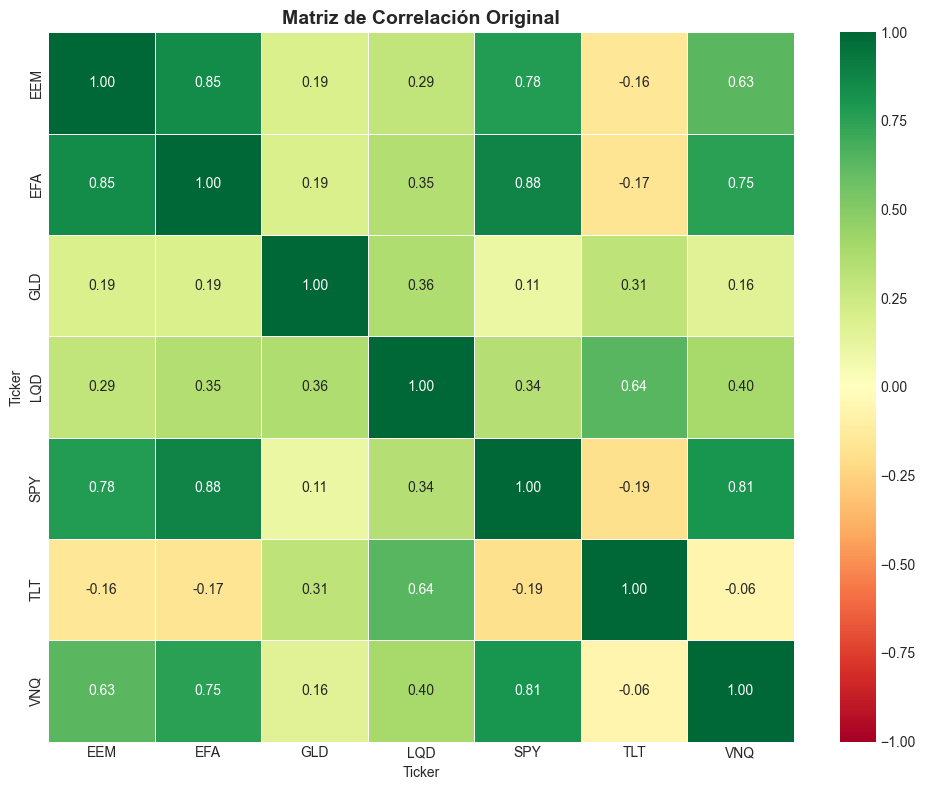


Observaciones:
- Los activos de renta variable (SPY, EFA, EEM, VNQ) muestran alta correlación entre sí
- TLT (bonos) y GLD (oro) tienen correlaciones más bajas con la renta variable
- Esta estructura será identificada por el clustering jerárquico


In [5]:
# Visualizar la matriz de correlación original
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- Los activos de renta variable (SPY, EFA, EEM, VNQ) muestran alta correlación entre sí")
print("- TLT (bonos) y GLD (oro) tienen correlaciones más bajas con la renta variable")
print("- Esta estructura será identificada por el clustering jerárquico")

## 4. Paso 1 de HRP: Transformación de Correlación a Distancia

### Concepto matemático

Para aplicar clustering jerárquico, necesitamos convertir las correlaciones en **distancias**. La intuición es:
- Activos con **alta correlación positiva** → **distancia pequeña** (son similares)
- Activos con **baja correlación o correlación negativa** → **distancia grande** (son diferentes)

La fórmula de transformación es:

$$d_{i,j} = \sqrt{\frac{1}{2}(1 - \rho_{i,j})}$$

Donde:
- $d_{i,j}$ es la distancia entre los activos $i$ y $j$
- $\rho_{i,j}$ es la correlación entre los activos $i$ y $j$

### Propiedades de esta métrica de distancia:
- Si $\rho = 1$ (correlación perfecta positiva) → $d = 0$ (distancia cero)
- Si $\rho = 0$ (sin correlación) → $d = 0.707$
- Si $\rho = -1$ (correlación perfecta negativa) → $d = 1$ (distancia máxima)

In [6]:
def correlacion_a_distancia(correlacion):
    """
    Convierte una matriz de correlación en una matriz de distancias.
    
    Parámetros:
    -----------
    correlacion : pd.DataFrame
        Matriz de correlación (valores entre -1 y 1)
    
    Retorna:
    --------
    pd.DataFrame
        Matriz de distancias (valores entre 0 y 1)
    
    La fórmula utilizada es: d = sqrt(0.5 * (1 - correlación))
    Esta transformación garantiza que:
    - Correlación = 1 → Distancia = 0 (activos idénticos)
    - Correlación = -1 → Distancia = 1 (activos opuestos)
    """
    # Aplicar la fórmula de transformación
    distancia = np.sqrt(0.5 * (1 - correlacion))
    return distancia

# Calcular la matriz de distancias
distancia = correlacion_a_distancia(correlacion)

print("Matriz de Distancias:")
print(distancia.round(3))

Matriz de Distancias:
Ticker    EEM    EFA    GLD    LQD    SPY    TLT    VNQ
Ticker                                                 
EEM     0.000  0.278  0.637  0.594  0.333  0.760  0.432
EFA     0.278  0.000  0.636  0.570  0.242  0.764  0.352
GLD     0.637  0.636  0.000  0.565  0.668  0.587  0.649
LQD     0.594  0.570  0.565  0.000  0.575  0.426  0.549
SPY     0.333  0.242  0.668  0.575  0.000  0.772  0.310
TLT     0.760  0.764  0.587  0.426  0.772  0.000  0.729
VNQ     0.432  0.352  0.649  0.549  0.310  0.729  0.000


## 5. Paso 2 de HRP: Clustering Jerárquico (Tree Clustering)

### ¿Qué es el Clustering Jerárquico?

El clustering jerárquico es una técnica de aprendizaje automático no supervisado que agrupa elementos en una estructura de árbol (dendrograma). En HRP utilizamos **clustering aglomerativo**, que funciona así:

1. **Inicio**: Cada activo comienza como su propio cluster
2. **Iteración**: En cada paso, se fusionan los dos clusters más cercanos
3. **Fin**: El proceso continúa hasta que todos los activos están en un solo cluster

### Método de enlace (Linkage)

HRP utiliza el método **"single linkage"** (enlace simple), donde la distancia entre dos clusters es la **distancia mínima** entre cualquier par de elementos de los clusters:

$$D(C_1, C_2) = \min_{i \in C_1, j \in C_2} d_{i,j}$$

Este método es preferido porque tiende a crear clusters "alargados" que preservan mejor la estructura de correlación.

In [7]:
def obtener_clustering_jerarquico(distancia, metodo='single'):
    """
    Realiza clustering jerárquico sobre la matriz de distancias.
    
    Parámetros:
    -----------
    distancia : pd.DataFrame
        Matriz de distancias entre activos
    metodo : str
        Método de enlace: 'single', 'complete', 'average', 'ward'
        - 'single': usa la distancia mínima entre clusters
        - 'complete': usa la distancia máxima entre clusters
        - 'average': usa el promedio de distancias
        - 'ward': minimiza la varianza dentro del cluster
    
    Retorna:
    --------
    np.ndarray
        Matriz de enlace (linkage matrix) con formato:
        [idx1, idx2, distancia, num_elementos]
    """
    # Convertir matriz de distancias a formato condensado
    # squareform convierte una matriz NxN simétrica a un vector de N*(N-1)/2 elementos
    distancia_condensada = squareform(distancia.values)
    
    # Realizar clustering jerárquico
    # La función linkage retorna una matriz donde cada fila representa una fusión
    enlace = linkage(distancia_condensada, method=metodo)
    
    return enlace

# Aplicar clustering jerárquico
enlace = obtener_clustering_jerarquico(distancia, metodo='single')

print("Matriz de enlace (linkage):")
print("Cada fila representa una fusión: [cluster1, cluster2, distancia, tamaño]")
print(enlace.round(4))

Matriz de enlace (linkage):
Cada fila representa una fusión: [cluster1, cluster2, distancia, tamaño]
[[ 1.      4.      0.2422  2.    ]
 [ 0.      7.      0.278   3.    ]
 [ 6.      8.      0.3104  4.    ]
 [ 3.      5.      0.4259  2.    ]
 [ 9.     10.      0.5488  6.    ]
 [ 2.     11.      0.5651  7.    ]]


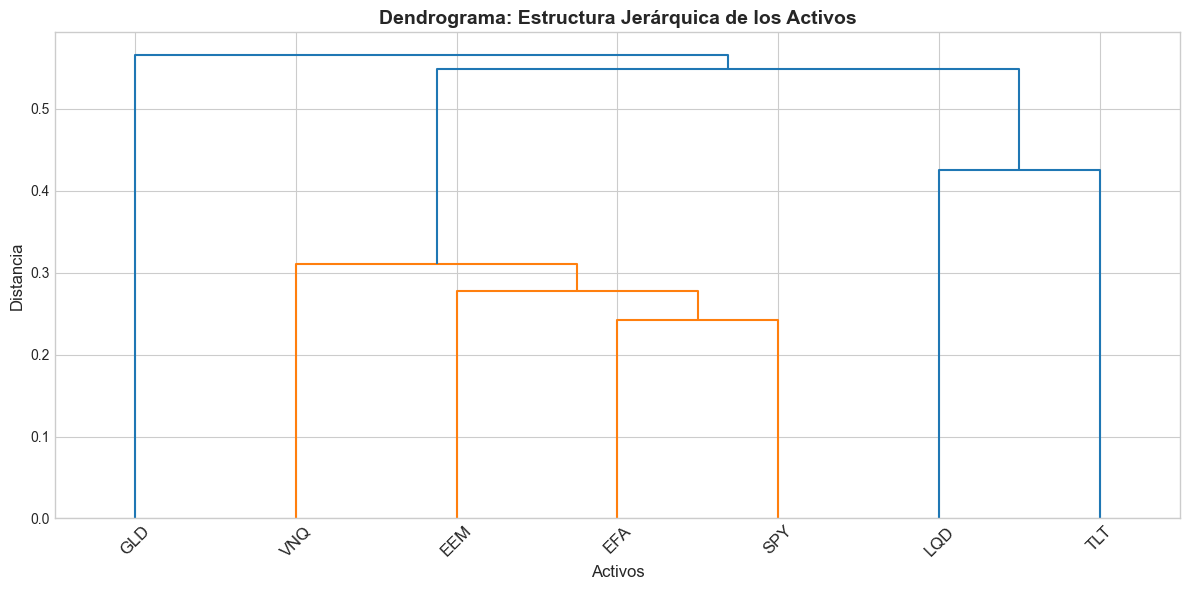


Interpretación del dendrograma:
- La altura de cada fusión indica la distancia entre los clusters fusionados
- Activos que se fusionan a menor altura son más similares
- El orden horizontal (de izquierda a derecha) es el orden quasi-diagonal


In [8]:
# Visualizar el dendrograma
fig, ax = plt.subplots(figsize=(12, 6))

# dendrogram crea una visualización jerárquica del clustering
dendrograma = dendrogram(
    enlace,
    labels=correlacion.columns.tolist(),
    leaf_rotation=45,
    leaf_font_size=12,
    ax=ax
)

ax.set_title('Dendrograma: Estructura Jerárquica de los Activos', fontsize=14, fontweight='bold')
ax.set_xlabel('Activos', fontsize=12)
ax.set_ylabel('Distancia', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretación del dendrograma:")
print("- La altura de cada fusión indica la distancia entre los clusters fusionados")
print("- Activos que se fusionan a menor altura son más similares")
print("- El orden horizontal (de izquierda a derecha) es el orden quasi-diagonal")

## 6. Paso 3 de HRP: Quasi-Diagonalización (Seriation)

### Concepto

La **quasi-diagonalización** reordena la matriz de covarianza de modo que los activos similares queden adyacentes. Esto crea una estructura donde:
- Las correlaciones más altas se concentran cerca de la diagonal
- Los activos de diferentes clusters quedan separados

El orden de los activos se obtiene directamente del dendrograma, leyendo las hojas de izquierda a derecha.

### ¿Por qué es importante?

Este reordenamiento es crucial para el paso de bisección recursiva, ya que permite dividir el portafolio de manera que cada subdivisión contenga activos verdaderamente similares.

In [9]:
def obtener_orden_quasi_diagonal(enlace, etiquetas):
    """
    Obtiene el orden de los activos para quasi-diagonalizar la matriz.
    
    Parámetros:
    -----------
    enlace : np.ndarray
        Matriz de enlace del clustering jerárquico
    etiquetas : list
        Lista de nombres de los activos
    
    Retorna:
    --------
    list
        Lista de activos en orden quasi-diagonal
    
    Este orden corresponde a leer las hojas del dendrograma de izquierda a derecha.
    """
    # leaves_list retorna los índices de las hojas en el orden del dendrograma
    orden_indices = leaves_list(enlace)
    
    # Convertir índices a nombres de activos
    orden_activos = [etiquetas[i] for i in orden_indices]
    
    return orden_activos

# Obtener el orden quasi-diagonal
orden_quasi_diagonal = obtener_orden_quasi_diagonal(enlace, correlacion.columns.tolist())

print("Orden original de los activos:", correlacion.columns.tolist())
print("Orden quasi-diagonal:", orden_quasi_diagonal)

Orden original de los activos: ['EEM', 'EFA', 'GLD', 'LQD', 'SPY', 'TLT', 'VNQ']
Orden quasi-diagonal: ['GLD', 'VNQ', 'EEM', 'EFA', 'SPY', 'LQD', 'TLT']


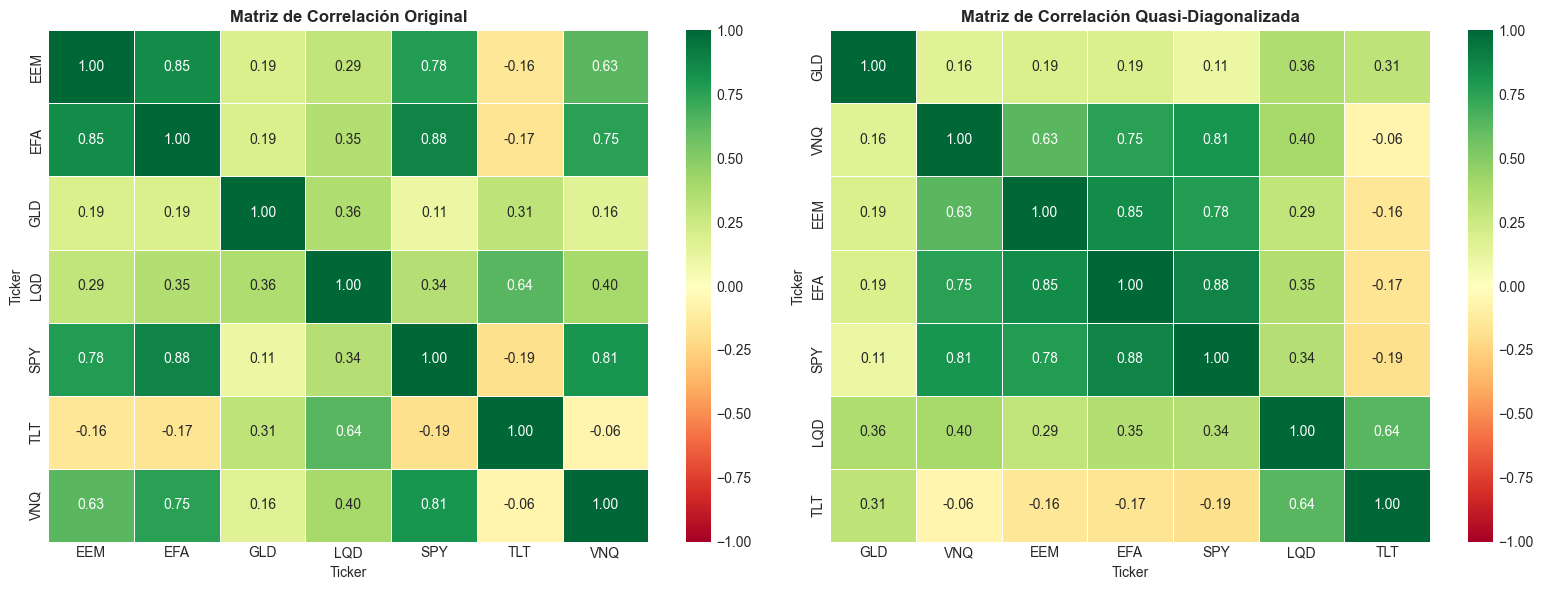


Observación importante:
En la matriz quasi-diagonalizada, las correlaciones altas se concentran cerca de la diagonal.
Esto facilita la bisección recursiva del portafolio.


In [10]:
# Reordenar la matriz de correlación según el orden quasi-diagonal
correlacion_reordenada = correlacion.loc[orden_quasi_diagonal, orden_quasi_diagonal]

# Comparar visualmente las matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz original
sns.heatmap(correlacion, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', linewidths=0.5, ax=axes[0],
            vmin=-1, vmax=1)
axes[0].set_title('Matriz de Correlación Original', fontsize=12, fontweight='bold')

# Matriz quasi-diagonalizada
sns.heatmap(correlacion_reordenada, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', linewidths=0.5, ax=axes[1],
            vmin=-1, vmax=1)
axes[1].set_title('Matriz de Correlación Quasi-Diagonalizada', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservación importante:")
print("En la matriz quasi-diagonalizada, las correlaciones altas se concentran cerca de la diagonal.")
print("Esto facilita la bisección recursiva del portafolio.")

## 7. Paso 4 de HRP: Bisección Recursiva (Recursive Bisection)

### El algoritmo de asignación de pesos

Este es el paso más innovador de HRP. En lugar de invertir la matriz de covarianza, HRP asigna pesos de forma **recursiva** mediante los siguientes pasos:

1. **Inicialización**: Asignar peso 1 a todo el portafolio
2. **División**: Dividir el portafolio en dos sub-portafolios según la estructura jerárquica
3. **Cálculo de varianza de cluster**: Para cada sub-portafolio, calcular su varianza usando paridad de riesgo inverso
4. **Asignación proporcional**: Distribuir el peso del nodo padre entre los hijos de forma inversamente proporcional a sus varianzas
5. **Recursión**: Repetir hasta llegar a activos individuales

### Fórmula de asignación

Para dos clusters $C_1$ y $C_2$ con varianzas $V_1$ y $V_2$, los pesos se asignan como:

$$w_1 = \frac{V_2}{V_1 + V_2}, \quad w_2 = \frac{V_1}{V_1 + V_2}$$

Esto asegura que el cluster más volátil reciba menos peso (paridad de riesgo inversa).

In [11]:
def calcular_varianza_cluster(covarianza, activos):
    """
    Calcula la varianza de un cluster de activos usando paridad de riesgo inversa.
    
    Parámetros:
    -----------
    covarianza : pd.DataFrame
        Matriz de covarianza completa
    activos : list
        Lista de activos en el cluster
    
    Retorna:
    --------
    float
        Varianza del cluster
    
    El cálculo usa pesos de paridad de riesgo inversa dentro del cluster:
    - Cada activo recibe peso inversamente proporcional a su varianza
    - La varianza del cluster es la varianza del portafolio resultante
    """
    # Extraer la submatriz de covarianza para los activos del cluster
    cov_cluster = covarianza.loc[activos, activos]
    
    # Calcular pesos de paridad de riesgo inversa
    # w_i ∝ 1/σ²_i (inversamente proporcional a la varianza)
    varianzas_individuales = np.diag(cov_cluster.values)
    pesos_inversos = 1 / varianzas_individuales
    pesos_normalizados = pesos_inversos / pesos_inversos.sum()
    
    # Calcular varianza del cluster: w' * Σ * w
    varianza_cluster = np.dot(pesos_normalizados, np.dot(cov_cluster.values, pesos_normalizados))
    
    return varianza_cluster

# Ejemplo: calcular varianza de un cluster
activos_ejemplo = ['SPY', 'EFA', 'EEM']
var_cluster_ejemplo = calcular_varianza_cluster(covarianza, activos_ejemplo)
print(f"Varianza del cluster {activos_ejemplo}: {var_cluster_ejemplo:.8f}")

Varianza del cluster ['SPY', 'EFA', 'EEM']: 0.00015672


In [12]:
def biseccion_recursiva(covarianza, orden_activos):
    """
    Implementa la bisección recursiva para calcular los pesos HRP.
    
    Parámetros:
    -----------
    covarianza : pd.DataFrame
        Matriz de covarianza
    orden_activos : list
        Lista de activos en orden quasi-diagonal
    
    Retorna:
    --------
    pd.Series
        Pesos del portafolio HRP
    
    Algoritmo:
    ----------
    1. Inicializar todos los activos con peso 1
    2. Usar una cola de segmentos a procesar
    3. Para cada segmento:
       a. Dividir en dos mitades
       b. Calcular varianza de cada mitad
       c. Asignar pesos inversamente proporcionales a las varianzas
    4. Retornar pesos finales normalizados
    """
    # Inicializar pesos: todos los activos comienzan con peso 1
    pesos = pd.Series(1.0, index=orden_activos)
    
    # Cola de segmentos a procesar: cada elemento es [inicio, fin]
    # Comenzamos con todo el rango de activos
    segmentos = [[0, len(orden_activos)]]
    
    while segmentos:
        # Tomar el siguiente segmento a procesar
        inicio, fin = segmentos.pop(0)
        
        # Si el segmento tiene más de un activo, dividirlo
        if fin - inicio > 1:
            # Encontrar el punto medio
            medio = (inicio + fin) // 2
            
            # Obtener activos de cada mitad
            activos_izq = orden_activos[inicio:medio]
            activos_der = orden_activos[medio:fin]
            
            # Calcular varianza de cada cluster
            var_izq = calcular_varianza_cluster(covarianza, activos_izq)
            var_der = calcular_varianza_cluster(covarianza, activos_der)
            
            # Calcular factor de asignación (paridad de riesgo inversa)
            # El cluster con mayor varianza recibe menos peso
            alpha = var_der / (var_izq + var_der)
            
            # Ajustar pesos
            pesos[activos_izq] *= alpha
            pesos[activos_der] *= (1 - alpha)
            
            # Agregar sub-segmentos a la cola si tienen más de un activo
            if medio - inicio > 1:
                segmentos.append([inicio, medio])
            if fin - medio > 1:
                segmentos.append([medio, fin])
    
    return pesos

# Calcular pesos HRP
pesos_hrp = biseccion_recursiva(covarianza, orden_quasi_diagonal)

print("Pesos del portafolio HRP:")
print(pesos_hrp.round(4))
print(f"\nSuma de pesos: {pesos_hrp.sum():.4f}")

Pesos del portafolio HRP:
GLD    0.2565
VNQ    0.0549
EEM    0.0697
EFA    0.0839
SPY    0.0745
LQD    0.3330
TLT    0.1276
dtype: float64

Suma de pesos: 1.0000


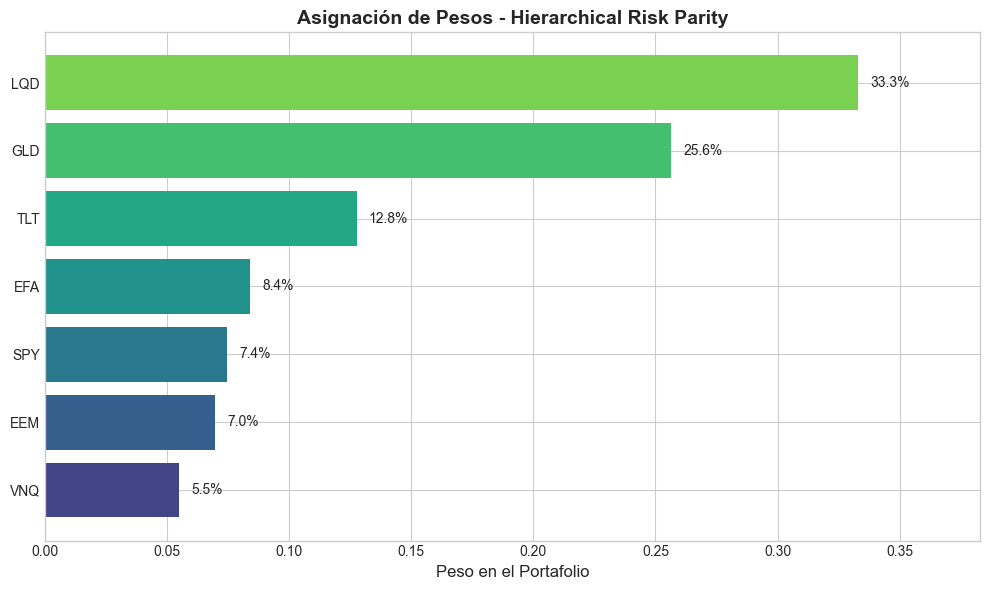


Interpretación de los pesos:
- Los activos con menor volatilidad y menor correlación reciben mayor peso
- La diversificación se logra tanto entre clusters como dentro de cada cluster


In [13]:
# Visualizar los pesos del portafolio HRP
fig, ax = plt.subplots(figsize=(10, 6))

# Ordenar por peso para mejor visualización
pesos_ordenados = pesos_hrp.sort_values(ascending=True)

# Crear gráfico de barras horizontales
colores = plt.cm.viridis(np.linspace(0.2, 0.8, len(pesos_ordenados)))
bars = ax.barh(pesos_ordenados.index, pesos_ordenados.values, color=colores)

# Añadir etiquetas de porcentaje
for bar, peso in zip(bars, pesos_ordenados.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{peso*100:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Peso en el Portafolio', fontsize=12)
ax.set_title('Asignación de Pesos - Hierarchical Risk Parity', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(pesos_ordenados) * 1.15)

plt.tight_layout()
plt.show()

print("\nInterpretación de los pesos:")
print("- Los activos con menor volatilidad y menor correlación reciben mayor peso")
print("- La diversificación se logra tanto entre clusters como dentro de cada cluster")

## 8. Implementación Completa: Clase HRP

A continuación, encapsulamos todo el algoritmo en una clase reutilizable que facilita su aplicación en diferentes contextos.

In [14]:
class HierarchicalRiskParity:
    """
    Implementación del algoritmo Hierarchical Risk Parity (HRP).
    
    Este algoritmo construye portafolios diversificados sin necesidad de invertir
    la matriz de covarianza, evitando así los problemas de inestabilidad numérica
    de los métodos tradicionales de optimización de portafolios.
    
    Atributos:
    ----------
    covarianza : pd.DataFrame
        Matriz de covarianza de los rendimientos
    correlacion : pd.DataFrame
        Matriz de correlación de los rendimientos
    distancia : pd.DataFrame
        Matriz de distancias derivada de las correlaciones
    enlace : np.ndarray
        Matriz de enlace del clustering jerárquico
    orden_quasi_diagonal : list
        Orden de activos después de la quasi-diagonalización
    pesos : pd.Series
        Pesos finales del portafolio
    
    Métodos:
    --------
    fit(rendimientos): Ajusta el modelo a los datos de rendimientos
    get_weights(): Retorna los pesos del portafolio
    plot_dendrogram(): Visualiza el dendrograma
    plot_correlation(): Visualiza las matrices de correlación
    plot_weights(): Visualiza la asignación de pesos
    """
    
    def __init__(self, metodo_enlace='single'):
        """
        Inicializa el modelo HRP.
        
        Parámetros:
        -----------
        metodo_enlace : str
            Método de enlace para clustering: 'single', 'complete', 'average', 'ward'
        """
        self.metodo_enlace = metodo_enlace
        self.covarianza = None
        self.correlacion = None
        self.distancia = None
        self.enlace = None
        self.orden_quasi_diagonal = None
        self.pesos = None
    
    def fit(self, rendimientos):
        """
        Ajusta el modelo HRP a los datos de rendimientos.
        
        Parámetros:
        -----------
        rendimientos : pd.DataFrame
            DataFrame con rendimientos de los activos (columnas = activos)
        
        Retorna:
        --------
        self : objeto HierarchicalRiskParity
        """
        # Paso 1: Calcular matrices de covarianza y correlación
        self.covarianza = rendimientos.cov()
        self.correlacion = rendimientos.corr()
        
        # Paso 2: Convertir correlación a distancia
        self.distancia = self._correlacion_a_distancia(self.correlacion)
        
        # Paso 3: Clustering jerárquico
        self.enlace = self._clustering_jerarquico(self.distancia)
        
        # Paso 4: Quasi-diagonalización
        self.orden_quasi_diagonal = self._quasi_diagonalizacion(
            self.enlace, self.correlacion.columns.tolist()
        )
        
        # Paso 5: Bisección recursiva
        self.pesos = self._biseccion_recursiva(
            self.covarianza, self.orden_quasi_diagonal
        )
        
        return self
    
    def _correlacion_a_distancia(self, correlacion):
        """Convierte correlación a distancia: d = sqrt(0.5 * (1 - ρ))"""
        return np.sqrt(0.5 * (1 - correlacion))
    
    def _clustering_jerarquico(self, distancia):
        """Realiza clustering jerárquico aglomerativo."""
        distancia_condensada = squareform(distancia.values)
        return linkage(distancia_condensada, method=self.metodo_enlace)
    
    def _quasi_diagonalizacion(self, enlace, etiquetas):
        """Obtiene el orden quasi-diagonal de los activos."""
        orden_indices = leaves_list(enlace)
        return [etiquetas[i] for i in orden_indices]
    
    def _calcular_varianza_cluster(self, covarianza, activos):
        """Calcula la varianza de un cluster usando paridad de riesgo inversa."""
        cov_cluster = covarianza.loc[activos, activos]
        varianzas_ind = np.diag(cov_cluster.values)
        pesos_inv = 1 / varianzas_ind
        pesos_norm = pesos_inv / pesos_inv.sum()
        return np.dot(pesos_norm, np.dot(cov_cluster.values, pesos_norm))
    
    def _biseccion_recursiva(self, covarianza, orden_activos):
        """Implementa la bisección recursiva para calcular pesos."""
        pesos = pd.Series(1.0, index=orden_activos)
        segmentos = [[0, len(orden_activos)]]
        
        while segmentos:
            inicio, fin = segmentos.pop(0)
            if fin - inicio > 1:
                medio = (inicio + fin) // 2
                activos_izq = orden_activos[inicio:medio]
                activos_der = orden_activos[medio:fin]
                
                var_izq = self._calcular_varianza_cluster(covarianza, activos_izq)
                var_der = self._calcular_varianza_cluster(covarianza, activos_der)
                
                alpha = var_der / (var_izq + var_der)
                pesos[activos_izq] *= alpha
                pesos[activos_der] *= (1 - alpha)
                
                if medio - inicio > 1:
                    segmentos.append([inicio, medio])
                if fin - medio > 1:
                    segmentos.append([medio, fin])
        
        return pesos
    
    def get_weights(self):
        """Retorna los pesos del portafolio."""
        if self.pesos is None:
            raise ValueError("Primero debe ajustar el modelo con fit()")
        return self.pesos
    
    def plot_dendrogram(self, figsize=(12, 6)):
        """Visualiza el dendrograma del clustering."""
        fig, ax = plt.subplots(figsize=figsize)
        dendrogram(self.enlace, labels=self.correlacion.columns.tolist(),
                   leaf_rotation=45, leaf_font_size=12, ax=ax)
        ax.set_title('Dendrograma HRP', fontsize=14, fontweight='bold')
        ax.set_xlabel('Activos')
        ax.set_ylabel('Distancia')
        plt.tight_layout()
        return fig
    
    def plot_weights(self, figsize=(10, 6)):
        """Visualiza los pesos del portafolio."""
        fig, ax = plt.subplots(figsize=figsize)
        pesos_ord = self.pesos.sort_values(ascending=True)
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(pesos_ord)))
        bars = ax.barh(pesos_ord.index, pesos_ord.values, color=colors)
        for bar, peso in zip(bars, pesos_ord.values):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{peso*100:.1f}%', va='center', fontsize=10)
        ax.set_xlabel('Peso')
        ax.set_title('Pesos HRP', fontsize=14, fontweight='bold')
        ax.set_xlim(0, max(pesos_ord) * 1.15)
        plt.tight_layout()
        return fig

Pesos del portafolio usando la clase HRP:
GLD    0.2565
VNQ    0.0549
EEM    0.0697
EFA    0.0839
SPY    0.0745
LQD    0.3330
TLT    0.1276
dtype: float64


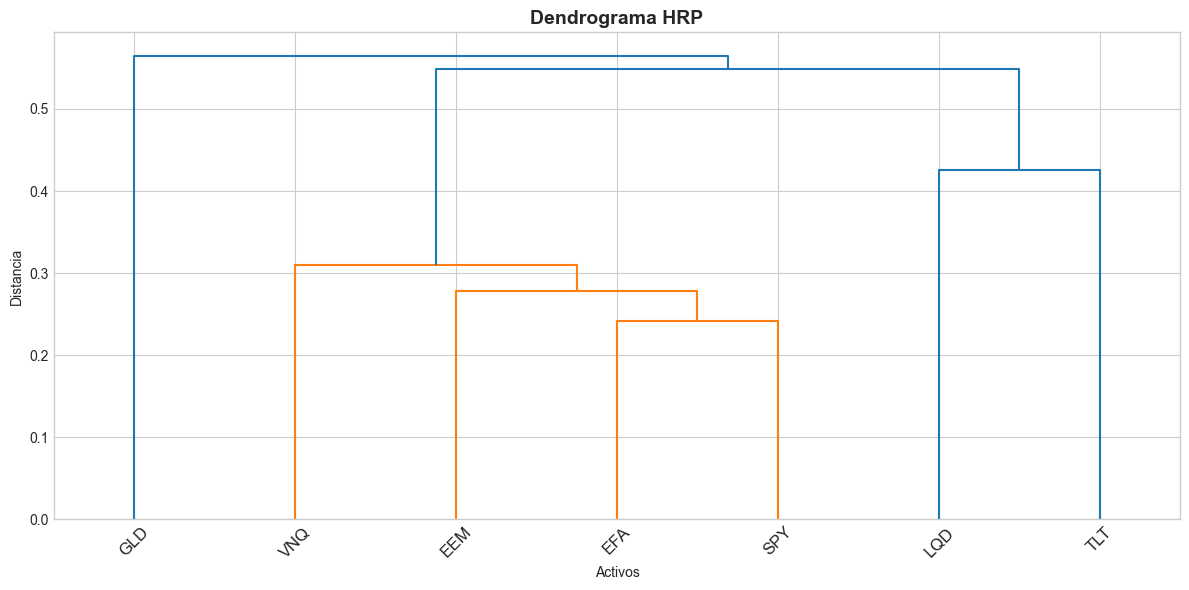

In [15]:
# Ejemplo de uso de la clase HierarchicalRiskParity
hrp = HierarchicalRiskParity(metodo_enlace='single')
hrp.fit(rendimientos)

print("Pesos del portafolio usando la clase HRP:")
print(hrp.get_weights().round(4))

# Visualizar el dendrograma
hrp.plot_dendrogram()
plt.show()

## 9. Comparación con Otros Métodos de Asignación

Comparemos los pesos de HRP con otros métodos comunes:
1. **Igual Ponderación (Equal Weight)**: Cada activo recibe el mismo peso
2. **Paridad de Riesgo Inversa (Inverse Volatility)**: Pesos inversamente proporcionales a la volatilidad individual
3. **Mínima Varianza**: Portafolio que minimiza la varianza total (requiere inversión de matriz)

In [16]:
def pesos_igual_ponderacion(activos):
    """Asigna pesos iguales a todos los activos."""
    n = len(activos)
    return pd.Series(1/n, index=activos)

def pesos_volatilidad_inversa(rendimientos):
    """Asigna pesos inversamente proporcionales a la volatilidad."""
    volatilidades = rendimientos.std()
    pesos_inv = 1 / volatilidades
    return pesos_inv / pesos_inv.sum()

def pesos_minima_varianza(covarianza):
    """
    Calcula los pesos del portafolio de mínima varianza.
    NOTA: Este método requiere invertir la matriz de covarianza.
    """
    # Invertir la matriz de covarianza
    cov_inv = np.linalg.inv(covarianza.values)
    unos = np.ones(len(covarianza))
    
    # w = Σ^(-1) * 1 / (1' * Σ^(-1) * 1)
    pesos = np.dot(cov_inv, unos)
    pesos = pesos / pesos.sum()
    
    return pd.Series(pesos, index=covarianza.columns)

# Calcular pesos con cada método
activos = rendimientos.columns.tolist()
pesos_ew = pesos_igual_ponderacion(activos)
pesos_iv = pesos_volatilidad_inversa(rendimientos)
pesos_mv = pesos_minima_varianza(covarianza)

# Crear DataFrame comparativo
comparacion = pd.DataFrame({
    'HRP': pesos_hrp,
    'Igual Pond.': pesos_ew,
    'Vol. Inversa': pesos_iv,
    'Min. Varianza': pesos_mv
})

print("Comparación de pesos por método:")
print(comparacion.round(4))

Comparación de pesos por método:
        HRP  Igual Pond.  Vol. Inversa  Min. Varianza
EEM  0.0697       0.1429        0.1119        -0.0067
EFA  0.0839       0.1429        0.1269         0.0608
GLD  0.2565       0.1429        0.1685         0.2475
LQD  0.3330       0.1429        0.2309         0.6032
SPY  0.0745       0.1429        0.1195         0.1740
TLT  0.1276       0.1429        0.1429         0.0451
VNQ  0.0549       0.1429        0.0993        -0.1238


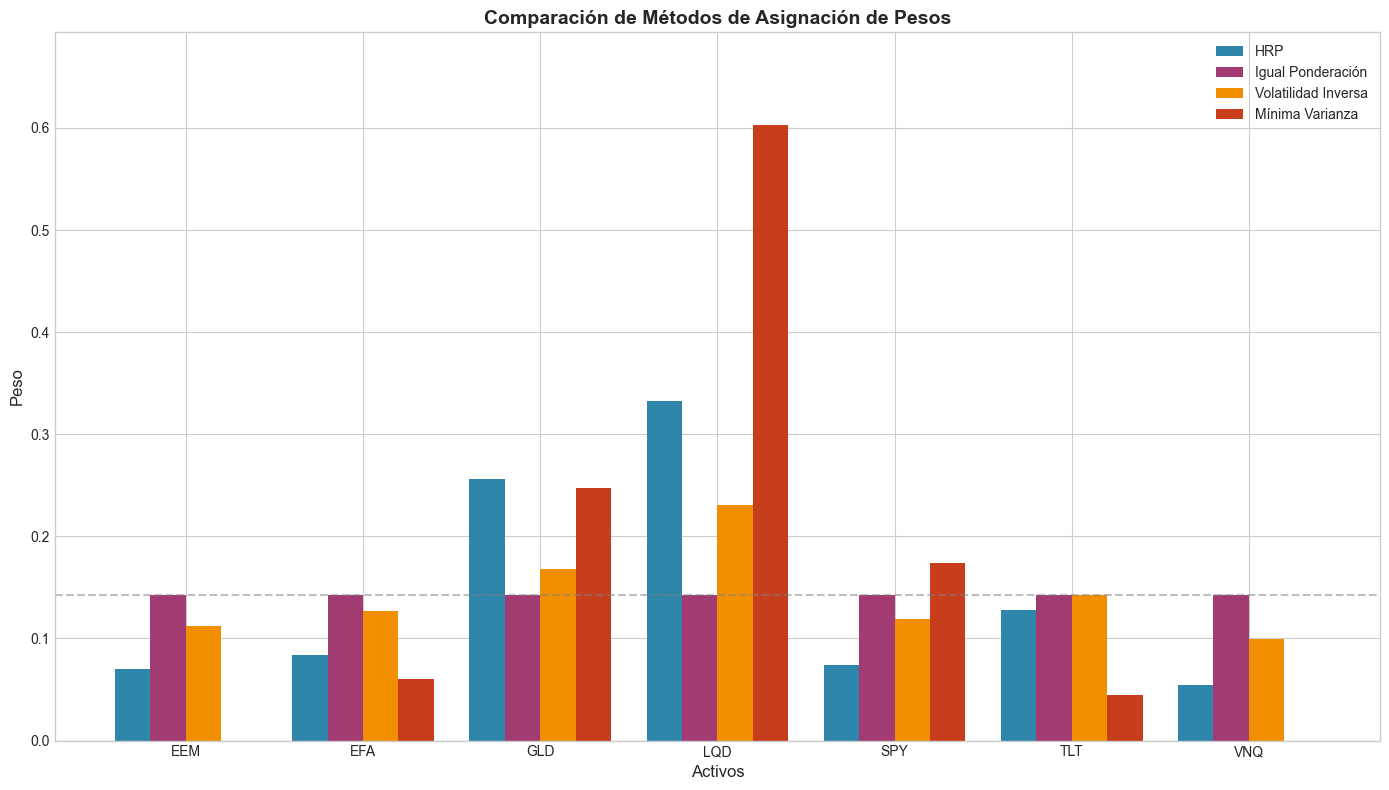

In [17]:
# Visualización comparativa de los métodos
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(activos))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comparacion['HRP'], width, label='HRP', color='#2E86AB')
bars2 = ax.bar(x - 0.5*width, comparacion['Igual Pond.'], width, label='Igual Ponderación', color='#A23B72')
bars3 = ax.bar(x + 0.5*width, comparacion['Vol. Inversa'], width, label='Volatilidad Inversa', color='#F18F01')
bars4 = ax.bar(x + 1.5*width, comparacion['Min. Varianza'], width, label='Mínima Varianza', color='#C73E1D')

ax.set_xlabel('Activos', fontsize=12)
ax.set_ylabel('Peso', fontsize=12)
ax.set_title('Comparación de Métodos de Asignación de Pesos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(activos)
ax.legend(loc='upper right')
ax.set_ylim(0, max(comparacion.max()) * 1.15)

# Añadir línea de referencia para igual ponderación
ax.axhline(y=1/len(activos), color='gray', linestyle='--', alpha=0.5, label='Referencia EW')

plt.tight_layout()
plt.show()

## 10. Análisis de Rendimiento de los Portafolios

Evaluemos el rendimiento histórico de cada estrategia utilizando métricas clave:
- **Rendimiento anualizado**
- **Volatilidad anualizada**
- **Ratio de Sharpe** (asumiendo tasa libre de riesgo = 0 para simplificar)
- **Máximo Drawdown**

In [18]:
def calcular_metricas_portafolio(rendimientos, pesos, dias_anuales=252):
    """
    Calcula las métricas de rendimiento de un portafolio.
    
    Parámetros:
    -----------
    rendimientos : pd.DataFrame
        Rendimientos diarios de los activos
    pesos : pd.Series
        Pesos del portafolio
    dias_anuales : int
        Número de días de trading por año
    
    Retorna:
    --------
    dict
        Diccionario con las métricas del portafolio
    """
    # Asegurar que los pesos estén en el mismo orden que los rendimientos
    pesos_alineados = pesos.reindex(rendimientos.columns)
    
    # Calcular rendimientos del portafolio
    rendimientos_portafolio = (rendimientos * pesos_alineados).sum(axis=1)
    
    # Rendimiento anualizado
    rendimiento_anual = rendimientos_portafolio.mean() * dias_anuales
    
    # Volatilidad anualizada
    volatilidad_anual = rendimientos_portafolio.std() * np.sqrt(dias_anuales)
    
    # Ratio de Sharpe (asumiendo rf = 0)
    sharpe_ratio = rendimiento_anual / volatilidad_anual if volatilidad_anual > 0 else 0
    
    # Máximo Drawdown
    rendimientos_acumulados = (1 + rendimientos_portafolio).cumprod()
    maximo_historico = rendimientos_acumulados.expanding().max()
    drawdowns = (rendimientos_acumulados - maximo_historico) / maximo_historico
    max_drawdown = drawdowns.min()
    
    return {
        'Rendimiento Anual': rendimiento_anual,
        'Volatilidad Anual': volatilidad_anual,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown
    }

# Calcular métricas para cada método
metricas = {}
for nombre, pesos in [('HRP', pesos_hrp), ('Igual Pond.', pesos_ew), 
                       ('Vol. Inversa', pesos_iv), ('Min. Varianza', pesos_mv)]:
    metricas[nombre] = calcular_metricas_portafolio(rendimientos, pesos)

# Crear DataFrame con las métricas
df_metricas = pd.DataFrame(metricas).T
df_metricas['Rendimiento Anual'] = df_metricas['Rendimiento Anual'].apply(lambda x: f"{x*100:.2f}%")
df_metricas['Volatilidad Anual'] = df_metricas['Volatilidad Anual'].apply(lambda x: f"{x*100:.2f}%")
df_metricas['Sharpe Ratio'] = df_metricas['Sharpe Ratio'].apply(lambda x: f"{x:.3f}")
df_metricas['Max Drawdown'] = df_metricas['Max Drawdown'].apply(lambda x: f"{x*100:.2f}%")

print("Métricas de Rendimiento por Estrategia:")
print(df_metricas)

Métricas de Rendimiento por Estrategia:
              Rendimiento Anual Volatilidad Anual Sharpe Ratio Max Drawdown
HRP                       5.34%            10.49%        0.509      -24.05%
Igual Pond.               6.09%            13.09%        0.465      -26.53%
Vol. Inversa              5.68%            11.79%        0.482      -25.75%
Min. Varianza             5.85%             9.80%        0.597      -22.14%


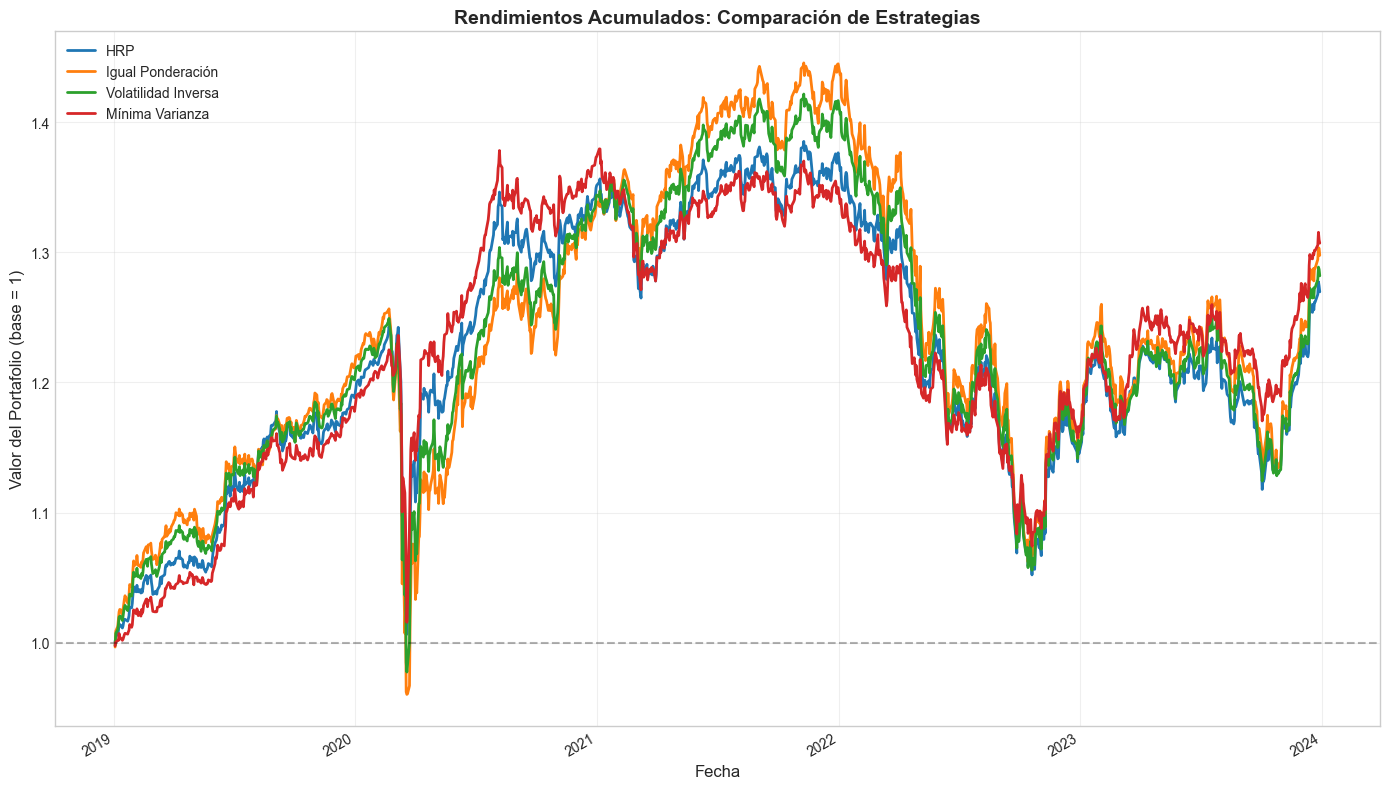

In [19]:
# Calcular rendimientos acumulados de cada estrategia
def calcular_rendimiento_acumulado(rendimientos, pesos):
    """Calcula los rendimientos acumulados del portafolio."""
    pesos_alineados = pesos.reindex(rendimientos.columns)
    rendimientos_portafolio = (rendimientos * pesos_alineados).sum(axis=1)
    return (1 + rendimientos_portafolio).cumprod()

# Crear DataFrame con rendimientos acumulados
rendimientos_acumulados = pd.DataFrame({
    'HRP': calcular_rendimiento_acumulado(rendimientos, pesos_hrp),
    'Igual Ponderación': calcular_rendimiento_acumulado(rendimientos, pesos_ew),
    'Volatilidad Inversa': calcular_rendimiento_acumulado(rendimientos, pesos_iv),
    'Mínima Varianza': calcular_rendimiento_acumulado(rendimientos, pesos_mv)
})

# Visualizar rendimientos acumulados
fig, ax = plt.subplots(figsize=(14, 8))

rendimientos_acumulados.plot(ax=ax, linewidth=2)

ax.set_title('Rendimientos Acumulados: Comparación de Estrategias', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor del Portafolio (base = 1)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Añadir línea de referencia
ax.axhline(y=1, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Ventajas de HRP sobre Métodos Tradicionales

### ¿Por qué evitar la inversión de la matriz de covarianza?

La inversión de la matriz de covarianza ($\Sigma^{-1}$) presenta varios problemas fundamentales:

In [20]:
# Demostración del problema de inestabilidad de la inversión de matriz
def demostrar_inestabilidad_inversion(covarianza, perturbacion=0.001):
    """
    Demuestra cómo pequeñas perturbaciones en la covarianza
    producen grandes cambios en los pesos de mínima varianza.
    """
    # Calcular condición de la matriz
    # Un número de condición alto indica inestabilidad
    num_condicion = np.linalg.cond(covarianza.values)
    
    # Calcular pesos originales
    pesos_original = pesos_minima_varianza(covarianza)
    
    # Perturbar ligeramente la matriz de covarianza
    np.random.seed(42)
    ruido = np.random.normal(0, perturbacion, covarianza.shape)
    ruido = (ruido + ruido.T) / 2  # Hacer simétrico
    
    cov_perturbada = covarianza + ruido
    
    # Calcular nuevos pesos
    pesos_perturbado = pesos_minima_varianza(cov_perturbada)
    
    # Calcular diferencia en pesos
    diferencia = (pesos_original - pesos_perturbado).abs()
    
    return num_condicion, pesos_original, pesos_perturbado, diferencia

num_cond, p_orig, p_pert, dif = demostrar_inestabilidad_inversion(covarianza)

print("="*60)
print("DEMOSTRACIÓN DE INESTABILIDAD EN INVERSIÓN DE MATRIZ")
print("="*60)
print(f"\nNúmero de condición de la matriz: {num_cond:.2f}")
print("(Valores > 30 indican matriz mal condicionada)")
print("\nCambio en pesos ante perturbación de 0.1% en la covarianza:")
print(pd.DataFrame({'Original': p_orig, 'Perturbado': p_pert, 'Diferencia': dif}).round(4))
print(f"\nCambio promedio en pesos: {dif.mean()*100:.2f}%")

DEMOSTRACIÓN DE INESTABILIDAD EN INVERSIÓN DE MATRIZ

Número de condición de la matriz: 50.29
(Valores > 30 indican matriz mal condicionada)

Cambio en pesos ante perturbación de 0.1% en la covarianza:
        Original  Perturbado  Diferencia
Ticker                                  
EEM      -0.0067     -0.5349      0.5281
EFA       0.0608      0.4116      0.3508
GLD       0.2475      0.7933      0.5458
LQD       0.6032     -0.1557      0.7589
SPY       0.1740      0.2409      0.0669
TLT       0.0451      0.0306      0.0145
VNQ      -0.1238      0.2142      0.3380

Cambio promedio en pesos: 37.19%


Comparando estabilidad (esto puede tomar unos segundos)...


/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_53003/1395041125.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([var_hrp, var_mv], labels=['HRP', 'Mínima Varianza'])


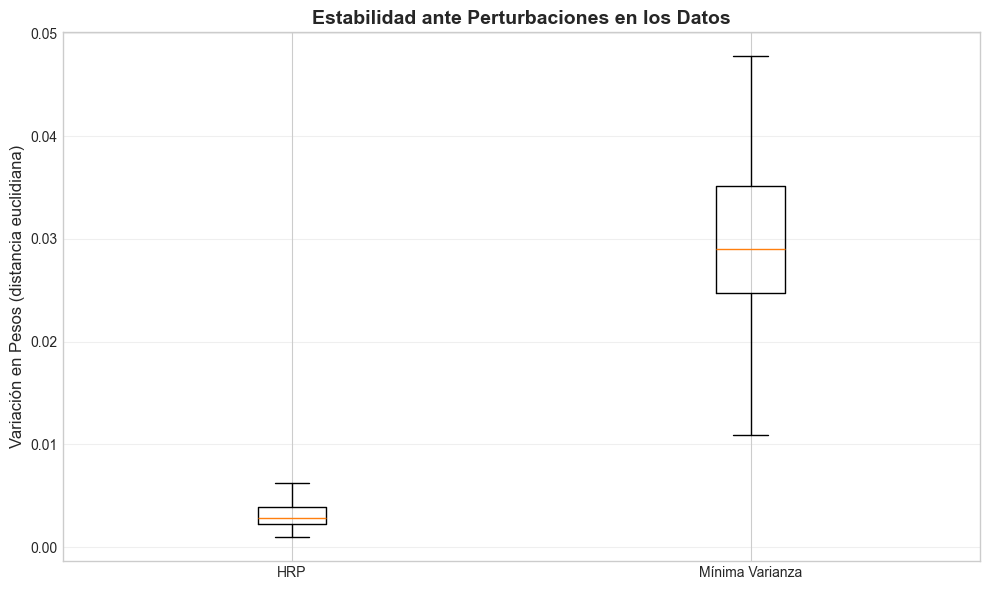


Variación promedio de pesos:
  HRP: 0.0032 (±0.0014)
  Mínima Varianza: 0.0295 (±0.0084)

HRP es 9.2x más estable que Mínima Varianza


In [21]:
# Comparar estabilidad de HRP vs Mínima Varianza
def comparar_estabilidad(rendimientos, n_simulaciones=50, perturbacion=0.001):
    """
    Compara la estabilidad de HRP vs Mínima Varianza
    mediante múltiples perturbaciones de los datos.
    """
    covarianza = rendimientos.cov()
    
    # Pesos originales
    hrp_original = HierarchicalRiskParity().fit(rendimientos).get_weights()
    mv_original = pesos_minima_varianza(covarianza)
    
    variaciones_hrp = []
    variaciones_mv = []
    
    for i in range(n_simulaciones):
        # Perturbar rendimientos
        np.random.seed(i)
        ruido = np.random.normal(0, perturbacion, rendimientos.shape)
        rendimientos_pert = rendimientos + ruido
        
        # Recalcular pesos
        hrp_pert = HierarchicalRiskParity().fit(rendimientos_pert).get_weights()
        cov_pert = rendimientos_pert.cov()
        mv_pert = pesos_minima_varianza(cov_pert)
        
        # Calcular variación (distancia euclidiana)
        variaciones_hrp.append(np.sqrt(((hrp_original - hrp_pert)**2).sum()))
        variaciones_mv.append(np.sqrt(((mv_original - mv_pert)**2).sum()))
    
    return variaciones_hrp, variaciones_mv

# Ejecutar comparación de estabilidad
print("Comparando estabilidad (esto puede tomar unos segundos)...")
var_hrp, var_mv = comparar_estabilidad(rendimientos, n_simulaciones=30)

# Visualizar resultados
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot([var_hrp, var_mv], labels=['HRP', 'Mínima Varianza'])
ax.set_ylabel('Variación en Pesos (distancia euclidiana)', fontsize=12)
ax.set_title('Estabilidad ante Perturbaciones en los Datos', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nVariación promedio de pesos:")
print(f"  HRP: {np.mean(var_hrp):.4f} (±{np.std(var_hrp):.4f})")
print(f"  Mínima Varianza: {np.mean(var_mv):.4f} (±{np.std(var_mv):.4f})")
print(f"\nHRP es {np.mean(var_mv)/np.mean(var_hrp):.1f}x más estable que Mínima Varianza")

## 12. Resumen del Algoritmo HRP

### Pasos del Algoritmo

```
┌──────────────────────────────────────────────────────────────┐
│                    ALGORITMO HRP                              │
├──────────────────────────────────────────────────────────────┤
│                                                               │
│  1. ENTRADA: Matriz de Rendimientos                          │
│         ↓                                                     │
│  2. Calcular Matriz de Correlación (ρ)                       │
│         ↓                                                     │
│  3. Transformar a Distancia: d = √(0.5 × (1-ρ))             │
│         ↓                                                     │
│  4. Clustering Jerárquico (Single Linkage)                   │
│         ↓                                                     │
│  5. Quasi-Diagonalización (ordenar activos)                  │
│         ↓                                                     │
│  6. Bisección Recursiva:                                      │
│      - Dividir portafolio en dos clusters                    │
│      - Calcular varianza de cada cluster                     │
│      - Asignar pesos: w ∝ 1/varianza                        │
│      - Repetir recursivamente                                 │
│         ↓                                                     │
│  7. SALIDA: Vector de Pesos Óptimos                          │
│                                                               │
└──────────────────────────────────────────────────────────────┘
```

### Ventajas Principales

| Característica | HRP | Markowitz/Min. Varianza |
|----------------|-----|-------------------------|
| Inversión de matriz | ❌ No requiere | ✅ Requiere $\Sigma^{-1}$ |
| Estabilidad numérica | ✅ Alta | ⚠️ Baja |
| Sensibilidad al ruido | ✅ Robusta | ⚠️ Muy sensible |
| Diversificación | ✅ Jerárquica | ⚠️ Puede concentrar |
| Interpretabilidad | ✅ Dendrograma visual | ⚠️ Caja negra |

### Limitaciones de HRP

1. **No optimiza directamente un objetivo**: A diferencia de Markowitz, HRP no maximiza el Sharpe ratio ni minimiza explícitamente la varianza.

2. **Dependencia del método de clustering**: Los resultados pueden variar según el método de enlace elegido.

3. **Asume simetría en correlaciones**: No distingue entre correlaciones positivas y negativas de manera óptima.

## 13. Referencias y Bibliografía

### Artículo Original
- López de Prado, M. (2016). **"Building Diversified Portfolios that Outperform Out-of-Sample"**. *Journal of Portfolio Management*, 42(4), 59-69.

### Recursos Adicionales
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley. Capítulos 16-17.
- Bailey, D. H., & López de Prado, M. (2012). "The Sharpe Ratio Efficient Frontier". *Journal of Risk*, 15(2).

### Conceptos Relacionados
- **Clustering Jerárquico**: Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. Capítulo 14.
- **Risk Parity**: Qian, E. (2006). "On the Financial Interpretation of Risk Contribution". *Journal of Investment Management*, 4(1).

### Implementaciones
- Librería `riskfolio-lib` en Python: implementación completa de HRP y otras estrategias
- Librería `PyPortfolioOpt`: incluye HRP con opciones avanzadas

## 14. Ejercicios Propuestos

### Ejercicio 1: Diferentes métodos de enlace
Modifica el método de enlace en el clustering jerárquico (`single`, `complete`, `average`, `ward`) y compara los resultados. ¿Cómo cambian los pesos del portafolio?

### Ejercicio 2: Aplicación a otros mercados
Aplica HRP a un conjunto de activos del mercado colombiano o mexicano. Utiliza tickers de acciones locales y analiza la estructura jerárquica resultante.

### Ejercicio 3: Rebalanceo periódico
Implementa una estrategia de rebalanceo trimestral usando HRP y compara el rendimiento contra una estrategia de "buy and hold" con pesos fijos.

### Ejercicio 4: HRP con restricciones
Modifica la implementación para incorporar restricciones de peso máximo por activo (por ejemplo, ningún activo puede superar el 25% del portafolio).

### Ejercicio 5: Análisis de sensibilidad
Estudia cómo cambian los pesos de HRP al variar el período de estimación (1 año, 3 años, 5 años de datos históricos).

Comparación de pesos según método de enlace:
     single  complete  average    ward
EEM  0.0697    0.0535   0.0535  0.0535
EFA  0.0839    0.0688   0.0688  0.0688
GLD  0.2565    0.2408   0.2408  0.2408
LQD  0.3330    0.3169   0.3169  0.3169
SPY  0.0745    0.1211   0.1211  0.1211
TLT  0.1276    0.1214   0.1214  0.1214
VNQ  0.0549    0.0775   0.0775  0.0775


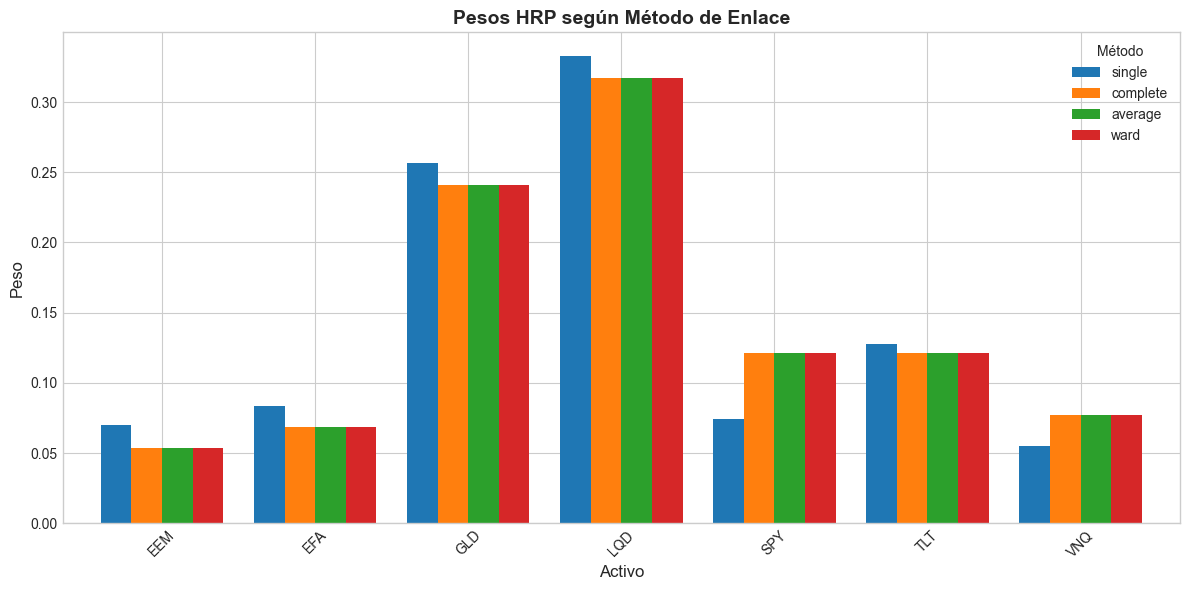

In [22]:
# Solución parcial Ejercicio 1: Comparación de métodos de enlace

metodos_enlace = ['single', 'complete', 'average', 'ward']
resultados_enlace = {}

for metodo in metodos_enlace:
    hrp_temp = HierarchicalRiskParity(metodo_enlace=metodo)
    hrp_temp.fit(rendimientos)
    resultados_enlace[metodo] = hrp_temp.get_weights()

# Crear DataFrame comparativo
df_comparacion_enlace = pd.DataFrame(resultados_enlace)
print("Comparación de pesos según método de enlace:")
print(df_comparacion_enlace.round(4))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
df_comparacion_enlace.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Activo', fontsize=12)
ax.set_ylabel('Peso', fontsize=12)
ax.set_title('Pesos HRP según Método de Enlace', fontsize=14, fontweight='bold')
ax.legend(title='Método')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()